# Classification of Ice and Open Water in Nizhnesvirsky Lower Bay using Sentinel-1 IW Product

This notebook classifies ice and open water in the Nizhnesvirsky lower bay using Sentinel-1 SAR imagery from September 2022 to April 2023.

## Imports

In [47]:
import datetime
import getpass

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import geopandas as gpd
import json
from ipyleaflet import Map, GeoJSON, basemaps

from sentinelhub import (
    SHConfig,
    Geometry,
    DataCollection,
    MimeType,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    bbox_to_dimensions,
)

## Credentials

Credentials (`client_id` & `client_secret`) can be obtained from your [Dashboard](https://shapps.dataspace.copernicus.eu/dashboard/#/) under User Settings > OAuth Clients.

Run the cell below only if you have **not** yet saved a CDSE profile. If you already have a saved profile, skip to the cell after.

In [48]:
# Only run this cell if you have not created a configuration profile yet.
config = SHConfig()
config.sh_client_id = "sh-03b97588-8780-4ec9-b187-9f18c5aa9b8e"
config.sh_client_secret = "yr1wbYiDybefN5L6utkT2KzwDPhq48rW"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"

## Defining the Bounds

Load the GeoJSON of the Nizhnesvirsky lower bay and display it on an interactive map.

In [49]:
SHAPE_PATH = "../data/raw/yukon_river.geojson"
river_gdf = gpd.read_file(SHAPE_PATH)

# Reproject temporarily just for metric resolution calculation
river_gdf_metric = river_gdf.to_crs("EPSG:32606")  # UTM zone 6N, meters-based
resolution = 40

# Keep river geometry in WGS84 for Sentinel Hub requests and visualization
river_gdf = river_gdf.to_crs("EPSG:4326")

data_geojson = json.load(open(SHAPE_PATH, "r"))

# Set center and zoom level
center = [64.79, -157.25]
zoom = 9

# Build and display interactive map
m = Map(basemap=basemaps.OpenStreetMap.Mapnik, center=center, zoom=zoom)
geo_json = GeoJSON(data=data_geojson)
m.add_layer(geo_json)
m

Map(center=[64.79, -157.25], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom…

### Define Time Slots

Split the September 2022 – April 2023 period into 16 bi-monthly slots to capture freeze-thaw dynamics.

In [50]:
start = datetime.datetime(2022, 9, 1)
end = datetime.datetime(2023, 4, 30)
n_chunks = 17
tdelta = (end - start) / n_chunks
edges = [(start + i * tdelta).date().isoformat() for i in range(n_chunks)]
slots = [(edges[i], edges[i + 1]) for i in range(len(edges) - 1)]

print("Monthly time windows:\n")
for slot in slots:
    print(slot)

Monthly time windows:

('2022-09-01', '2022-09-15')
('2022-09-15', '2022-09-29')
('2022-09-29', '2022-10-13')
('2022-10-13', '2022-10-27')
('2022-10-27', '2022-11-10')
('2022-11-10', '2022-11-25')
('2022-11-25', '2022-12-09')
('2022-12-09', '2022-12-23')
('2022-12-23', '2023-01-06')
('2023-01-06', '2023-01-20')
('2023-01-20', '2023-02-03')
('2023-02-03', '2023-02-18')
('2023-02-18', '2023-03-04')
('2023-03-04', '2023-03-18')
('2023-03-18', '2023-04-01')
('2023-04-01', '2023-04-15')


## Requesting Sentinel-1 (SAR) Data

The evalscript below:
- Inputs the VV band and dataMask
- Converts linear backscatter to decibels (dB), scaled to [0, 1]
- Outputs FLOAT32 values for further analysis

Pre-processing applied:
- **Radiometric calibration**: `SIGMA0_ELLIPSOID`
- **Speckle filter**: LEE 3×3
- **Geometric correction**: COPERNICUS DEM
- **Resolution**: HIGH (20 m × 20 m), ascending orbit

In [51]:
evalscript_sar = """
  function setup() {
    return {
      input: ["VV", "dataMask"],
      output: { bands: 2, sampleType: "FLOAT32"}
    }
  }

// visualizes decibels from -20 to +10
function toDb(linear) {
  var log = 10 * Math.log(linear) / Math.LN10
  return Math.max(0, (log + 20) / 30)
}

function evaluatePixel(sample) {
  var VV = sample.VV;
  return [toDb(VV), sample.dataMask];
}
"""


def get_sar_request(time_interval):
    return SentinelHubRequest(
        evalscript=evalscript_sar,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL1_IW.define_from(
                    "s1iw", service_url=config.sh_base_url
                ),
                time_interval=time_interval,
                other_args={
                    "dataFilter": {
                        "resolution": "HIGH",
                        "mosaickingOrder": "mostRecent",
                        "orbitDirection": "ASCENDING",
                    },
                    "processing": {
                        "backCoeff": "SIGMA0_ELLIPSOID",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS",
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 3,
                            "windowSizeY": 3,
                        },
                    },
                },
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        geometry=Geometry(river_gdf_metric.geometry.values[0], crs=river_gdf_metric.crs),
        resolution=[40, 40],
        config=config,
        data_folder="../data/results",
    )

In [52]:
# Create and download all SAR requests
list_of_requests = [get_sar_request(slot) for slot in slots]
list_of_requests = [request.download_list[0] for request in list_of_requests]

data = SentinelHubDownloadClient(config=config).download(
    list_of_requests, max_threads=5
)

### Visualise SAR Imagery (VV Band)

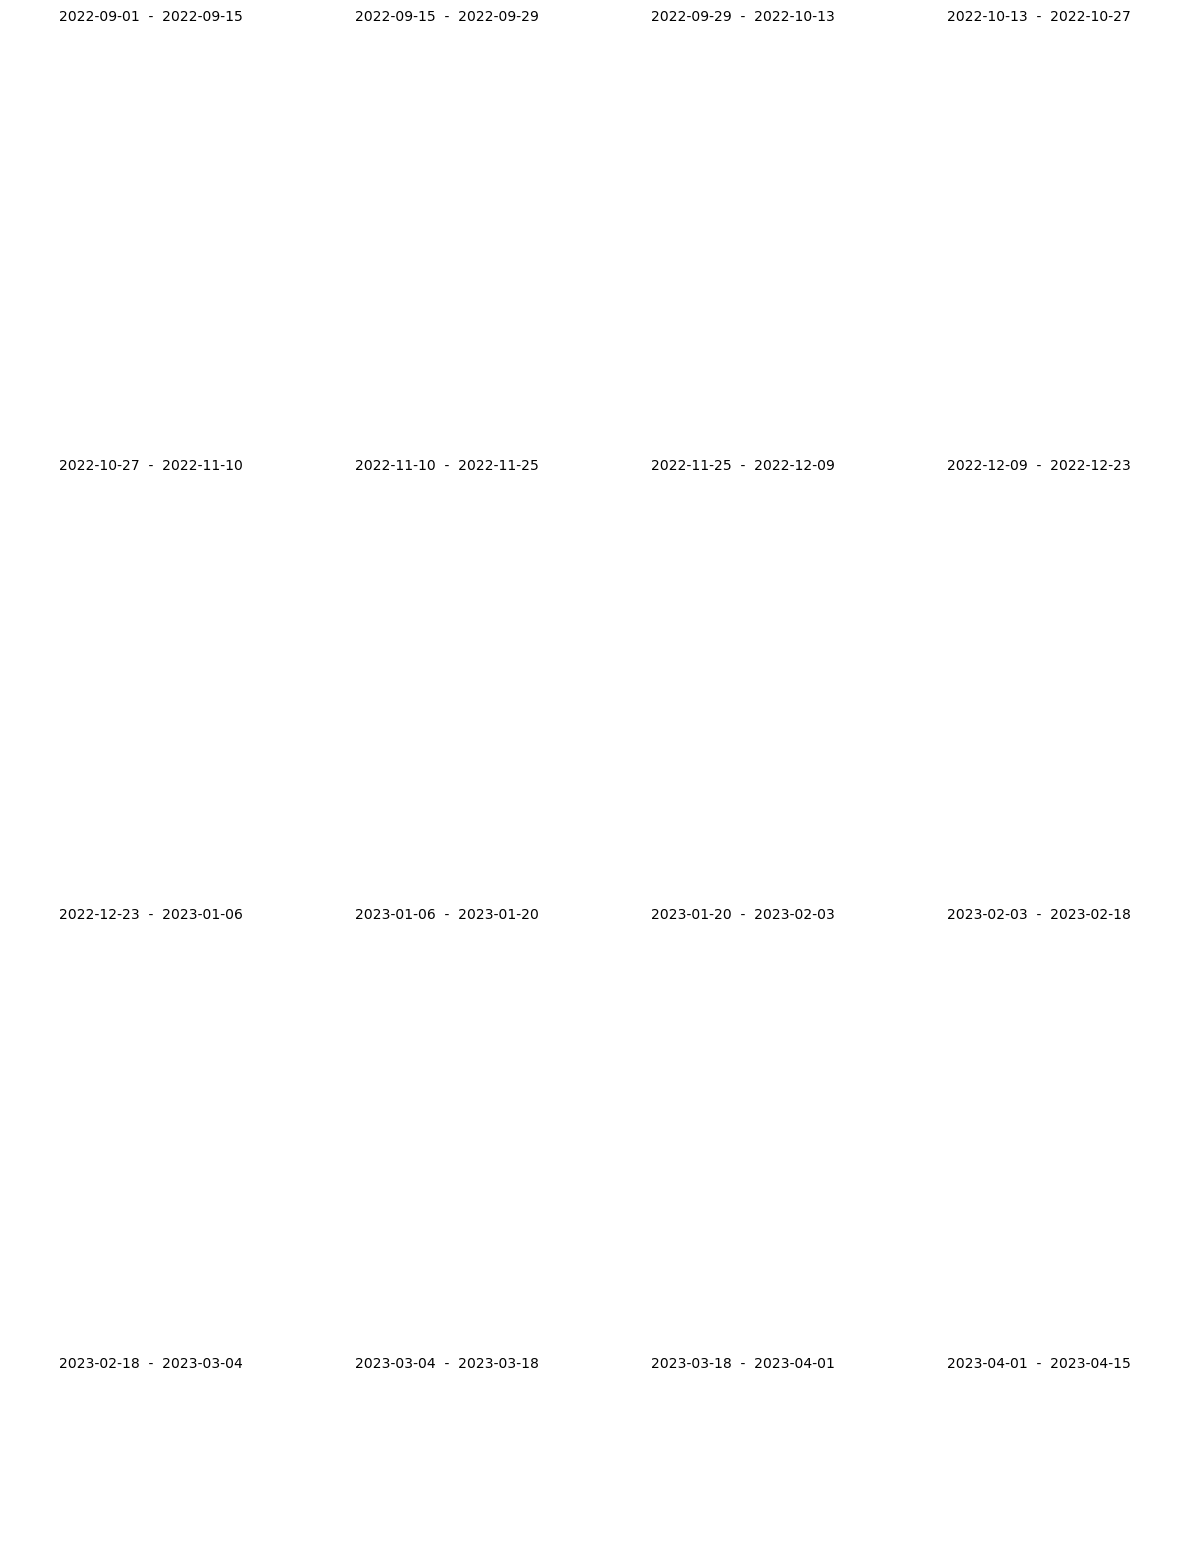

In [53]:
ncols = 4
nrows = 4
aspect_ratio = 1.5
subplot_kw = {"xticks": [], "yticks": [], "frame_on": False}

fig, axs = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(2 * ncols * aspect_ratio, 5 * nrows),
    subplot_kw=subplot_kw,
)

for idx, image in enumerate(data):
    ax = axs[idx // ncols][idx % ncols]
    ax.imshow(np.clip((image[:, :, 0]) * 3.5 / 255, 0, 1))
    ax.set_title(f"{slots[idx][0]}  -  {slots[idx][1]}", fontsize=10)

plt.tight_layout()
plt.show()

## Estimating a Threshold

Plot the histogram of VV pixel values for each time slot. Ice pixels appear brighter (higher backscatter) compared to open water.

Based on historic weather data and SAR image interpretation, ice began forming at the end of November and persisted until mid-March. A threshold at pixel value **50/255 ≈ 0.2** (in the normalised 0–1 scale) is used to separate ice from open water.

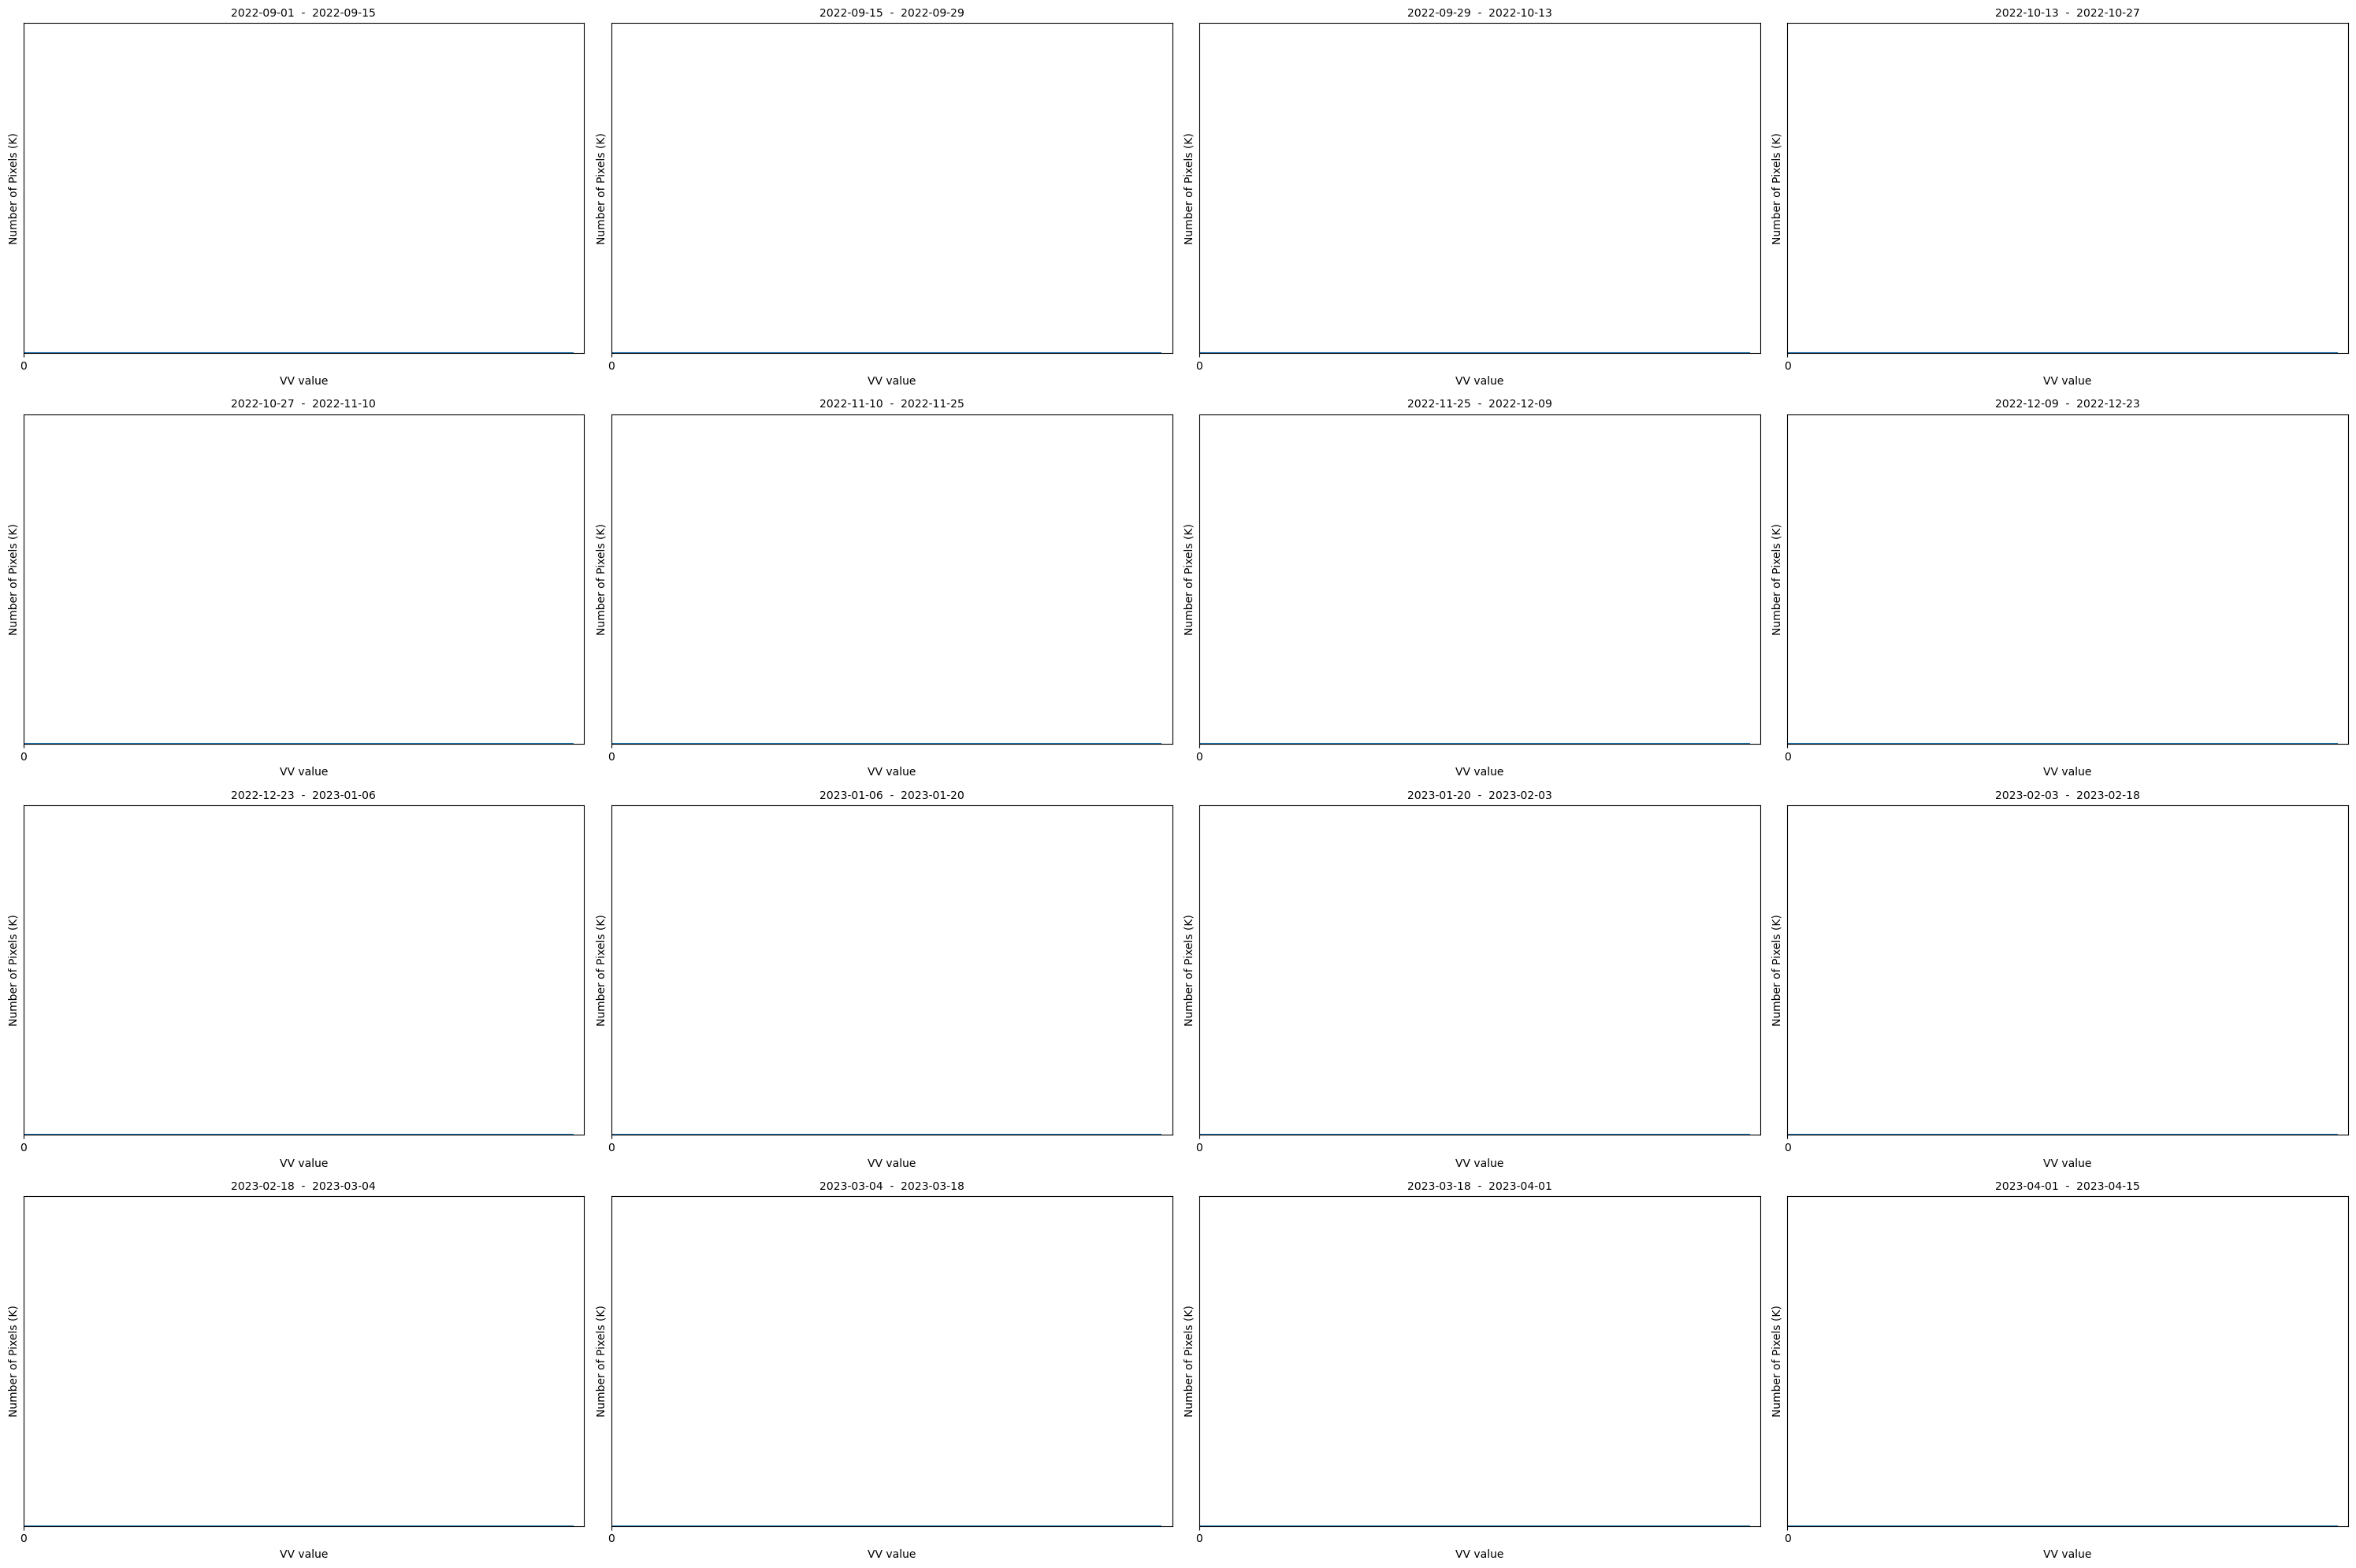

In [54]:
ncols = 4
nrows = 4
aspect_ratio = 15 / 10
subplot_kw = {"xticks": range(0, 255, 25), "yticks": [], "frame_on": True}

fig, axs = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(5 * ncols * aspect_ratio, 5 * nrows),
    subplot_kw=subplot_kw,
)

for idx, image in enumerate(data):
    histogram, bin_edges = np.histogram(
        2.5 * image[:, :, 0], bins=50, range=(0.0000001, 1)
    )
    ax = axs[idx // ncols][idx % ncols]
    ax.plot(bin_edges[0:-1], histogram)
    ax.set_xlabel("VV value")
    ax.set_ylabel("Number of Pixels (K)")
    ax.set_xlim((0, 1))
    ax.set_ylim((0, 500))
    ax.set_title(f"{slots[idx][0]}  -  {slots[idx][1]}", fontsize=10)

plt.tight_layout()
plt.show()

## Ice Mask Evalscript and Requests

The evalscript below classifies each pixel:
- **Blue** `[0, 0, 255]` → Open water (VV dB in [0, 0.2])
- **Cyan** `[0, 255, 255]` → Ice (VV dB in [0.2, 1])
- **Black** `[0, 0, 0]` → No data / land

Band 5 (`iceMask`) is `1` for ice pixels and `0` otherwise.

In [55]:
evalscript_mask = """
  function setup() {
    return {
      input: ["VV", "dataMask"],
      output: { bands: 5, sampleType: "UINT8"}
    }
  }

function toDb(linear) {
  var log = 10 * Math.log(linear) / Math.LN10
  return Math.max(0, (log + 20) / 30)
}

function evaluatePixel(sample) {
  var VV = sample.VV;
  var iceMask = 0;
  VVdB = toDb(VV);
  if (VVdB > -0.001 && VVdB < 0.2) {
    iceMask = 0;
    return [0, 0, 255, sample.dataMask, iceMask]; // Water
  } else if (VVdB > 0.2 && VVdB < 1) {
    iceMask = 1;
    return [0, 255, 255, sample.dataMask, iceMask]; // Ice
  } else {
    iceMask = 0;
    return [0, 0, 0, sample.dataMask, iceMask]; // No data
  }
}
"""


def get_ice_mask_request(time_interval):
    return SentinelHubRequest(
        evalscript=evalscript_mask,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL1_IW.define_from(
                    "s1iw", service_url=config.sh_base_url
                ),
                time_interval=time_interval,
                other_args={
                    "dataFilter": {
                        "resolution": "HIGH",
                        "mosaickingOrder": "mostRecent",
                        "orbitDirection": "ASCENDING",
                    },
                    "processing": {
                        "backCoeff": "SIGMA0_ELLIPSOID",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS",
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 3,
                            "windowSizeY": 3,
                        },
                    },
                },
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        geometry=Geometry(river_gdf_metric.geometry.values[0], crs=river_gdf_metric.crs),
        resolution=[40, 40],
        config=config,
        data_folder="./results_mask",
    )

In [56]:
# Download ice mask data
list_of_requests = [get_ice_mask_request(slot) for slot in slots]
list_of_requests = [request.download_list[0] for request in list_of_requests]

mask_data = SentinelHubDownloadClient(config=config).download(
    list_of_requests, max_threads=5
)

### Visualise Ice / Water Classification Maps

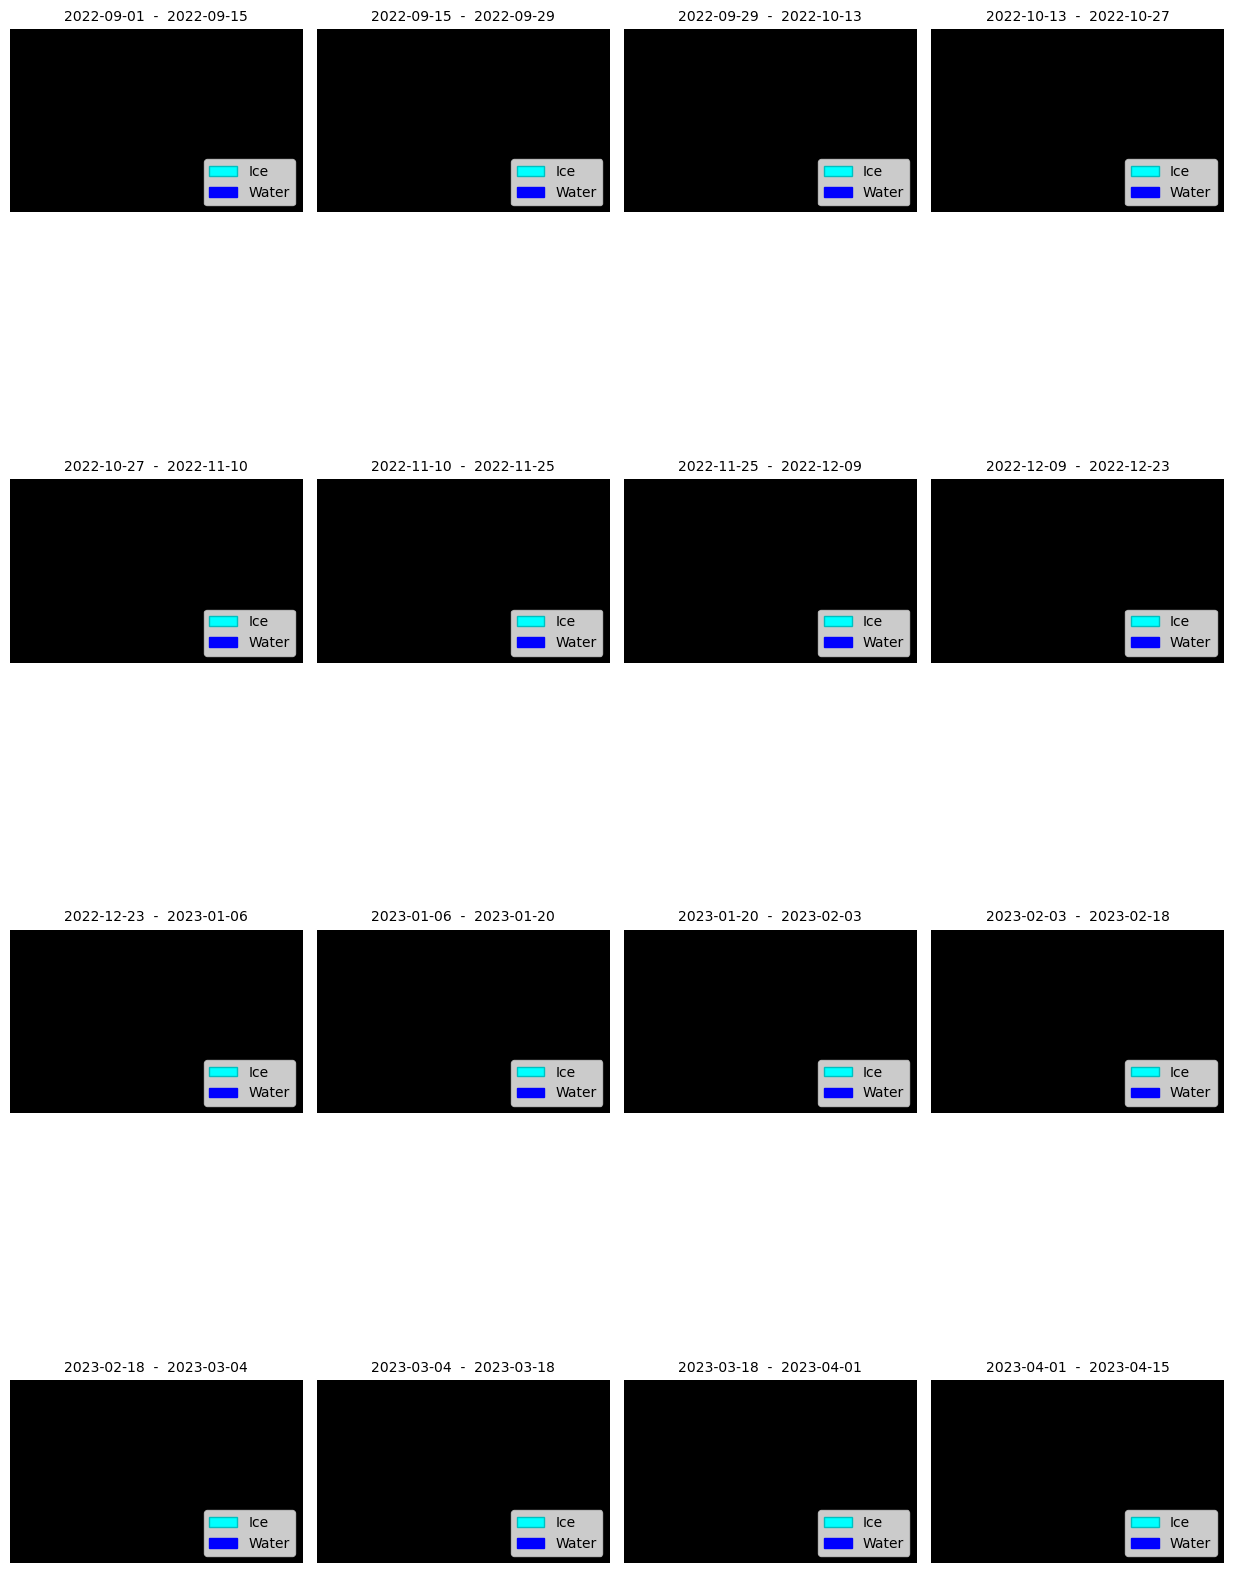

In [57]:
ncols = 4
nrows = 4
aspect_ratio = 1131 / 1819
subplot_kw = {"xticks": [], "yticks": [], "frame_on": False}
legend_elements = [
    Patch(facecolor="cyan", edgecolor="c", label="Ice"),
    Patch(facecolor="blue", edgecolor="b", label="Water"),
]

fig, axs = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(5 * ncols * aspect_ratio, 5 * nrows),
    subplot_kw=subplot_kw,
)

for idx, image in enumerate(mask_data):
    ax = axs[idx // ncols][idx % ncols]
    ax.imshow(np.clip(image[:, :, :3], 0, 255))
    ax.set_title(f"{slots[idx][0]}  -  {slots[idx][1]}", fontsize=10)
    ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

## Creating a Time Series of Ice-Covered Area

Count ice pixels (band 5 == 1) and multiply by the pixel area (20 m × 20 m) to get area in km².

In [58]:
def count_ice_pixels(image):
    ice_mask = image[:, :, 4]
    return np.sum(ice_mask)

In [59]:
resolution_s1 = 20 * 20  # m² per pixel
area_covered_ice = []

for idx, image in enumerate(mask_data):
    ice_pixels_count = count_ice_pixels(image)
    area_covered_ice.append(ice_pixels_count * resolution_s1 / 1_000_000)  # km²

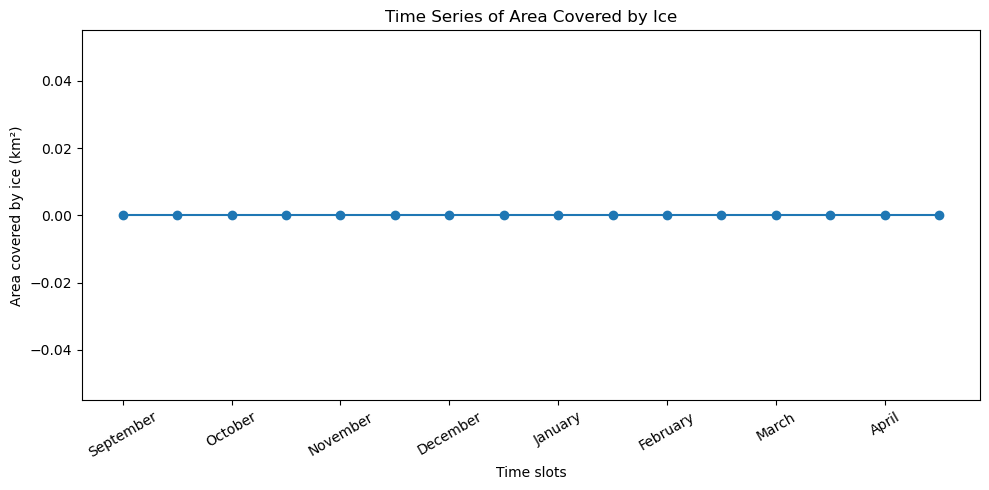

In [60]:
xlabels = [
    "September",
    "October",
    "November",
    "December",
    "January",
    "February",
    "March",
    "April",
]

plt.figure(figsize=(10, 5))
plt.plot(range(len(slots)), area_covered_ice, marker="o")
plt.title("Time Series of Area Covered by Ice")
plt.xticks(np.arange(0, 16, step=2), xlabels, rotation=30, ha="center")
plt.xlabel("Time slots")
plt.ylabel("Area covered by ice (km²)")
plt.tight_layout()
plt.show()

## Summary

- Ice formation in the Nizhnesvirsky lower bay began in **mid-to-late November 2022** and peaked through the winter months.
- Once ice breakup began in **mid-March 2023**, the river cleared rapidly.
- The classification used a VV dB threshold of **0.2** to separate open water (low backscatter) from ice (high backscatter).
- Sentinel-1 SAR data is well-suited for this task as it is unaffected by cloud cover or daylight conditions.